## Detect Cyber Intrusion Using Machine Learning

### Task 1: Import Libraries and Modules

In [2]:
import pandas as pd 
import numpy as np 
import time
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Task 2: Preprocess the Dataset

#### Load CSV file into a DataFrame

In [3]:
df = pd.read_csv("/usercode/SIMARGL2021.csv")

#### Display the first few rows of the CSV file


In [4]:
df.head(1)

,BIFLOW_DIRECTION,DIRECTION,DST_TO_SRC_SECOND_BYTES,FIREWALL_EVENT,FIRST_SWITCHED,FLOW_ACTIVE_TIMEOUT,FLOW_DURATION_MICROSECONDS,FLOW_DURATION_MILLISECONDS,FLOW_END_MILLISECONDS,FLOW_END_SEC,...,TCP_WIN_MSS_IN,TCP_WIN_MSS_OUT,TCP_WIN_SCALE_IN,TCP_WIN_SCALE_OUT,SRC_TOS,DST_TOS,L7_PROTO_NAME,SAMPLING_INTERVAL,TOTAL_FLOWS_EXP,LABEL
0,1,0,138,0,1622174400,120,682,0,1.622170e+12,1622174400,...,0,0,0,0,0,0,DNS,1,1365973,Normal flow


#### Select the 15 features

In [5]:
selected_columns = [
'DST_TOS', 'SRC_TOS', 'TCP_WIN_SCALE_OUT', 'TCP_WIN_SCALE_IN', 'TCP_FLAGS','TCP_WIN_MAX_OUT', 'PROTOCOL', 'TCP_WIN_MIN_OUT', 'TCP_WIN_MIN_IN','TCP_WIN_MAX_IN', 'LAST_SWITCHED', 'TCP_WIN_MSS_IN', 'TOTAL_FLOWS_EXP','FIRST_SWITCHED', 'FLOW_DURATION_MILLISECONDS', 'LABEL'
]
df  = df[selected_columns]
df.head()

,DST_TOS,SRC_TOS,TCP_WIN_SCALE_OUT,TCP_WIN_SCALE_IN,TCP_FLAGS,TCP_WIN_MAX_OUT,PROTOCOL,TCP_WIN_MIN_OUT,TCP_WIN_MIN_IN,TCP_WIN_MAX_IN,LAST_SWITCHED,TCP_WIN_MSS_IN,TOTAL_FLOWS_EXP,FIRST_SWITCHED,FLOW_DURATION_MILLISECONDS,LABEL
0,0,0,0,0,0,0,17,0,0,0,1622174400,0,1365973,1622174400,0,Normal flow
1,0,0,0,0,0,0,17,0,0,0,1622174400,0,1365974,1622174400,0,Normal flow
2,40,40,0,0,22,0,6,0,1024,1024,1622174400,0,1365976,1622174400,0,Normal flow
3,0,0,0,0,0,0,17,0,0,0,1622174400,0,1365978,1622174400,0,Normal flow
4,0,196,0,0,0,0,1,0,0,0,1622174400,0,1365979,1622174400,0,Normal flow


#### Remove duplicate rows

In [6]:
df.drop_duplicates(inplace=True)

### Task 3: Explore the Dataset

#### Display each label and its count via a bar graph


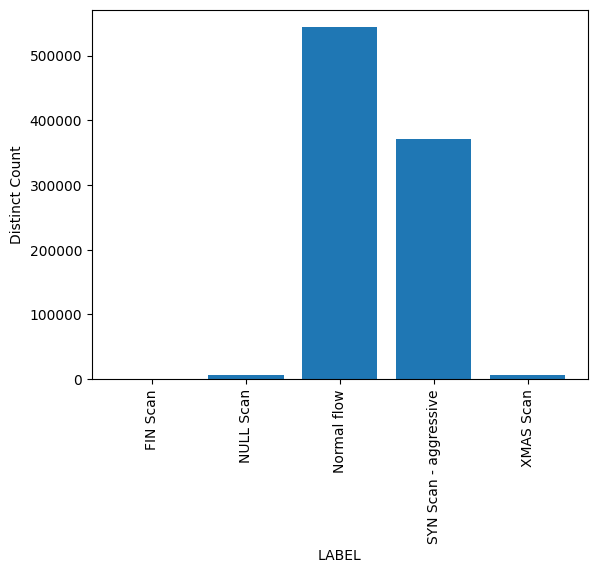

In [7]:
grouped_data = df.groupby('LABEL').size()
fig, ax = plt.subplots(1)
ax.bar(grouped_data.index, grouped_data.values)
ax.set(xlabel='LABEL', ylabel='Distinct Count')
plt.xticks(rotation=90)
plt.show()

#### Plot the distinct counts

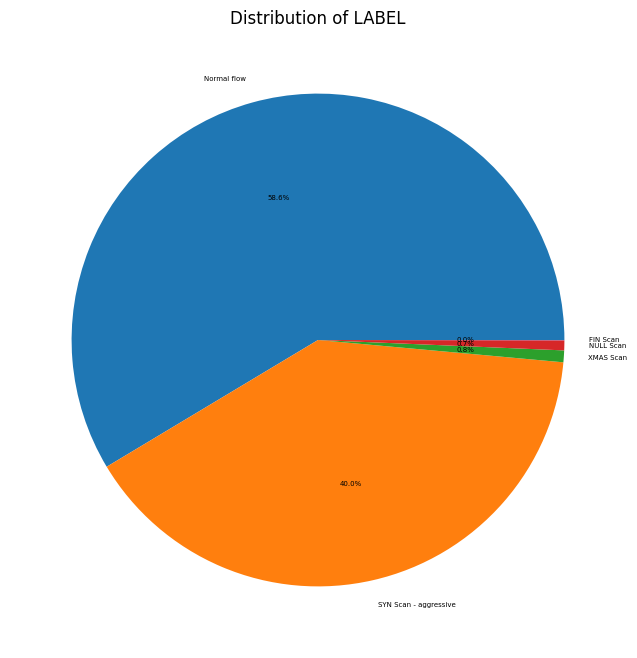

In [8]:
grouped_data = df['LABEL'].value_counts()
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(grouped_data.values, labels=grouped_data.index, autopct='%1.1f%%', textprops={'fontsize': 5})
ax.set_title('Distribution of LABEL')
plt.show()

### Task 4: Standardize and Encode the Data

#### Create a copy of the data

In [9]:
df_normalized = df.copy()

#### Extract the numerical columns to be normalized

In [10]:
numeric_columns = df_normalized.select_dtypes(include=['float64','int64']).columns

#### Extract the non-numerical columns to be label encoded

In [11]:
non_numeric_columns = df_normalized.select_dtypes(exclude = ['float64','int64']).columns

#### Standardize the numerical columns

In [12]:
labelencoder = LabelEncoder()
df_normalized[non_numeric_columns] = df_normalized[non_numeric_columns].apply(labelencoder.fit_transform)

In [13]:
scaler = StandardScaler()
df_normalized[numeric_columns] = scaler.fit_transform(df_normalized[numeric_columns])

In [14]:
df_normalized.head()

,DST_TOS,SRC_TOS,TCP_WIN_SCALE_OUT,TCP_WIN_SCALE_IN,TCP_FLAGS,TCP_WIN_MAX_OUT,PROTOCOL,TCP_WIN_MIN_OUT,TCP_WIN_MIN_IN,TCP_WIN_MAX_IN,LAST_SWITCHED,TCP_WIN_MSS_IN,TOTAL_FLOWS_EXP,FIRST_SWITCHED,FLOW_DURATION_MILLISECONDS,LABEL
0,-0.202520,-0.275953,-0.304294,-0.340399,-1.094170,-0.296931,1.602891,-0.296429,-0.373770,-0.377188,0.798357,-1.065921,-0.822983,0.798359,-0.199755,2
1,-0.202520,-0.275953,-0.304294,-0.340399,-1.094170,-0.296931,1.602891,-0.296429,-0.373770,-0.377188,0.798357,-1.065921,-0.822982,0.798359,-0.199755,2
2,1.521307,0.913199,-0.304294,-0.340399,0.773889,-0.296931,-0.512673,-0.296429,-0.312306,-0.316160,0.798357,-1.065921,-0.822981,0.798359,-0.199755,2
3,-0.202520,-0.275953,-0.304294,-0.340399,-1.094170,-0.296931,1.602891,-0.296429,-0.373770,-0.377188,0.798357,-1.065921,-0.822980,0.798359,-0.199755,2
4,-0.202520,5.550894,-0.304294,-0.340399,-1.094170,-0.296931,-1.474293,-0.296429,-0.373770,-0.377188,0.798357,-1.065921,-0.822979,0.798359,-0.199755,2


### Task 5: Separate Labels and Split Data into Train and Test Subsets

#### Separate data and labels

In [15]:
X = df_normalized.drop(columns = ['LABEL'], axis=1)
y = df_normalized['LABEL']

#### Split data into train and test subsets


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

### Task 6: Train Random Forest

#### Create a random forest classifier

In [19]:
rf = RandomForestClassifier(n_estimators=30)

#### Measure the training time

In [20]:
start = time.time()
rf.fit(X_train,y_train)
end = time.time()
rf_train_time = end-start

### Task 7: Test Random Forest

#### Make predictions on the test set


In [21]:
y_pred = rf.predict(X_test)

#### Calculate and print the accuracy, F1 score, precision, and recall

In [24]:
acc_rf = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred,average="weighted")
precision = precision_score(y_test, y_pred,average="weighted")
recall = recall_score(y_test,y_pred, average="weighted")
print(acc_rf)
print(f1)
print(precision)
print(recall)

0.9987749324596195
0.9987820866482829
0.9987912429791227
0.9987749324596195


### Task 8: Train Decision Tree

#### Create a DecisionTreeClassifier with criterion='entropy' and max_depth=4

In [25]:
dt = DecisionTreeClassifier(criterion='entropy',max_depth=4)

#### Measure the training time


In [29]:
start = time.time()
dt.fit(X_train, y_train)
end = time.time()
train_time_dt = end-start

### Task 9: Test Decision Tree

#### Make predictions on the test set

In [27]:
y_pred = dt.predict(X_test)

#### Calculate and print the accuracy, F1 score, precision, and recall

In [31]:
accuracyDT = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')  
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Training time:", train_time_dt)
print("Accuracy:", accuracyDT)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Training time: 1.7079708576202393
Accuracy: 0.9955416163706386
F1 Score: 0.9958178302361127
Precision: 0.99660519387782
Recall: 0.9955416163706386


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Task 10: Train Naive Bayes

#### Create a Gaussian Naive Bayes classifier

In [32]:
nb_classifier = GaussianNB()

#### Measure the training time

In [33]:
start_time = time.time()
nb_classifier.fit(X_train, y_train)
end_time = time.time()
training_timeNB = end_time - start_time

### Task 11: Test Naive Bayes

#### Make predictions on the test dataset

In [34]:
y_pred = nb_classifier.predict(X_test)

#### Calculate and print the accuracy, F1 sore, precision, and recall

In [35]:
accuracyNB = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, 
average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
print("Training time:", training_timeNB)
print("Accuracy:", accuracyNB)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Training time: 0.3014259338378906
Accuracy: 0.9915143415531413
F1 Score: 0.9927443386195428
Precision: 0.9952793972471476
Recall: 0.9915143415531413


### Task 12: Compare the Accuracy and Training Times

#### Accuracy scores and training time of the three algorithms

In [39]:
accuracy_scores = [acc_rf, accuracyDT, accuracyNB]
train_times = [rf_train_time, train_time_dt, training_timeNB]

#### Names of the algorithms

In [41]:
algorithm_names = ['Random Forest', 'Decision Tree', 'Gaussian Naive Bayes']

#### Create a bar plot for accuracy

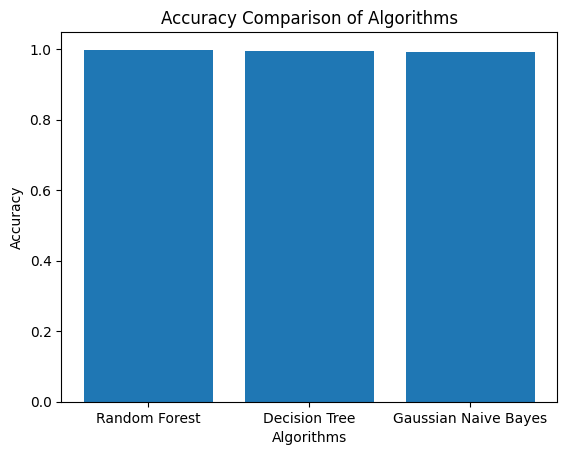

In [42]:
plt.bar(algorithm_names, accuracy_scores)
plt.xlabel('Algorithms')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Algorithms')
plt.show()

#### Create a bar plot for training time

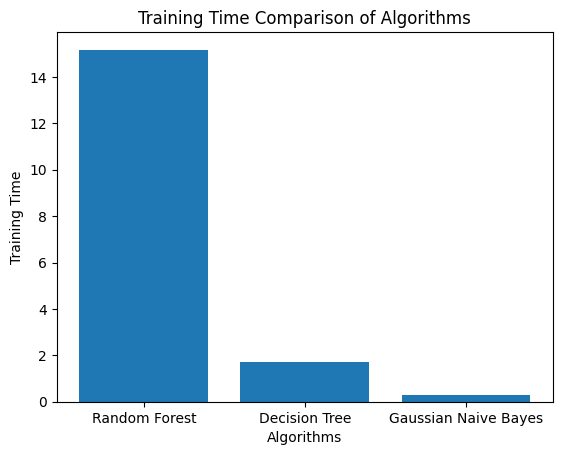

In [43]:
plt.bar(algorithm_names, train_times)
plt.xlabel('Algorithms')
plt.ylabel('Training Time')
plt.title('Training Time Comparison of Algorithms')
plt.show()